# 实验作业一：使用 PyTorch 设计更好的神经网络

本实验以 sklearn 内置的 `load_digits` 手写数字数据集为对象，使用 PyTorch 从零实现多层感知器（MLP）分类器。实验先建立一个结构简单的基线模型，再围绕激活函数、网络结构、优化器、学习率与正则化等因素进行控制变量对比，最后组合有效改进并复测。

所有曲线和汇总数据均由本次运行生成，保存于 `results/` 文件夹；报告中的数值与结论应以这些实际结果为准。

## 实验记录说明

代码按实验指导书的顺序组织：环境与数据准备、基线实验、逐项改进、失败实验、最优组合复测与结果汇总。每个实验组都保留独立配置、曲线文件和最终指标，便于回看改动内容并整理实验报告。TRAE 的实际协作过程、提示词和修改记录另行据实写入报告。

In [18]:
from pathlib import Path
import csv
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Windows 中文图形显示；若在非 Windows 系统出现字体警告，可改为本机可用中文字体。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

DATA_SPLIT_SEED = 42
MODEL_SEED = 42
EPOCHS = 30
RESULT_DIR = Path('results')
RESULT_DIR.mkdir(exist_ok=True)

print('PyTorch:', torch.__version__)
print('CUDA 可用:', torch.cuda.is_available())
print('结果保存目录:', RESULT_DIR.resolve())

PyTorch: 2.6.0+cu124
CUDA 可用: True
结果保存目录: C:\Users\momijiee\Desktop\hit\大模型基础与应用探索\lesson1\results


In [19]:
def set_seed(seed: int) -> None:
    """固定模型初始化等随机性；数据划分始终使用 DATA_SPLIT_SEED。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# 数据：load_digits 共 1797 个 8×8 灰度手写数字。
X, y = load_digits(return_X_y=True)
X = X.astype(np.float32) / 16.0  # 归一化到 [0, 1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=DATA_SPLIT_SEED
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
# CrossEntropyLoss 要求类别标签为 LongTensor，Windows 上原始标签常为 int32。
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(f'训练集: {X_train.shape}, 测试集: {X_test.shape}')
print('标签类型:', y_train.dtype)

训练集: torch.Size([1437, 64]), 测试集: torch.Size([360, 64])
标签类型: torch.int64


In [20]:
class MLP(nn.Module):
    """隐藏层结构、激活函数、Dropout 和 BatchNorm 均可配置的 MLP。"""
    def __init__(self, hidden=(32,), activation='sigmoid', dropout=0.0, use_batchnorm=False):
        super().__init__()
        activations = {
            'sigmoid': nn.Sigmoid,
            'tanh': nn.Tanh,
            'relu': nn.ReLU,
            'gelu': nn.GELU,
        }
        if activation not in activations:
            raise ValueError(f'不支持的激活函数: {activation}')

        layers, in_features = [], 64
        for width in hidden:
            layers.append(nn.Linear(in_features, width))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(width))
            layers.append(activations[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = width
        layers.append(nn.Linear(in_features, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [21]:
def train_and_evaluate(config, seed=MODEL_SEED):
    """按给定配置全批量训练，返回每 epoch 指标及总耗时。"""
    set_seed(seed)
    model = MLP(
        hidden=config['hidden'],
        activation=config['activation'],
        dropout=config.get('dropout', 0.0),
        use_batchnorm=config.get('use_batchnorm', False),
    )

    if config['optimizer'] == 'sgd':
        optimizer = torch.optim.SGD(
            model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0.0)
        )
    elif config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0.0)
        )
    else:
        raise ValueError("optimizer 只能是 'sgd' 或 'adam'")

    loss_fn = nn.CrossEntropyLoss()
    history = {'loss': [], 'test_acc': []}
    start = time.perf_counter()

    for _ in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)                 # 前向传播
        loss = loss_fn(logits, y_train)        # 损失计算
        loss.backward()                        # 反向传播
        optimizer.step()                       # 参数更新

        model.eval()
        with torch.no_grad():
            test_acc = (model(X_test).argmax(dim=1) == y_test).float().mean().item()
        history['loss'].append(loss.item())
        history['test_acc'].append(test_acc)

    history['seconds'] = time.perf_counter() - start
    return history


def save_curve(history, title, filename):
    """保存同时含损失与测试准确率的曲线图。"""
    epochs = np.arange(1, EPOCHS + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history['loss'], color='#1f77b4', marker='o', markersize=3)
    axes[0].set_title(f'{title}：训练损失')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, np.array(history['test_acc']) * 100, color='#d62728', marker='o', markersize=3)
    axes[1].set_title(f'{title}：测试准确率')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].grid(alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    output = RESULT_DIR / filename
    fig.savefig(output, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return output

## 基线与控制变量实验

为保证比较公平，全部实验采用相同的数据划分（训练集 80%、测试集 20%、分层抽样）和随机种子。第 1–7 组均相对基线只考察一个设计因素；第 8 组才综合前述实验中验证有效的改进。

In [ ]:
# 基线配置：64 → 32(Sigmoid) → 10，SGD(lr=0.1)，无正则化。
baseline = dict(hidden=(32,), activation='sigmoid', optimizer='sgd', lr=0.1, weight_decay=0.0, dropout=0.0, use_batchnorm=False)

records = {}

def run_experiment(number, name, config, image_name):
    """运行一组实验、显示曲线，并把真实结果加入汇总表。"""
    print(f'开始运行：{name}')
    history = train_and_evaluate(config, seed=MODEL_SEED)
    image_path = save_curve(history, name, image_name)
    records[number] = {'组号': number, '实验名称': name,
                    '测试准确率(%)': round(history['test_acc'][-1] * 100, 2),
                    '训练耗时(s)': round(history['seconds'], 4),
                    '曲线文件': str(image_path), '配置': str(config)}
    print(f"最终测试准确率：{history['test_acc'][-1] * 100:.2f}%；训练耗时：{history['seconds']:.4f}s")
    return history


def show_records(rows):
    """在 Notebook 中打印易读的结果表。"""
    if not rows:
        return
    keys = list(rows[0].keys())
    print(' | '.join(keys))
    print('-' * 100)
    for row in rows:
        print(' | '.join(str(row.get(key, '')) for key in keys))


def save_records_csv(rows, filename):
    """使用 Python 标准库保存 UTF-8 CSV。"""
    if not rows:
        return
    output = RESULT_DIR / filename
    with output.open('w', newline='', encoding='utf-8-sig') as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0].keys()), extrasaction='ignore')
        writer.writeheader()
        writer.writerows(rows)
    print('已保存：', output)

### 1. 基线实验

基线模型为 `64 → 32(Sigmoid) → 10`，采用 SGD（学习率 0.1）训练 30 个 epoch，不使用 L2 正则化、Dropout 或 BatchNorm。该组给出后续各项改进的比较参照。

开始运行：基线 Baseline


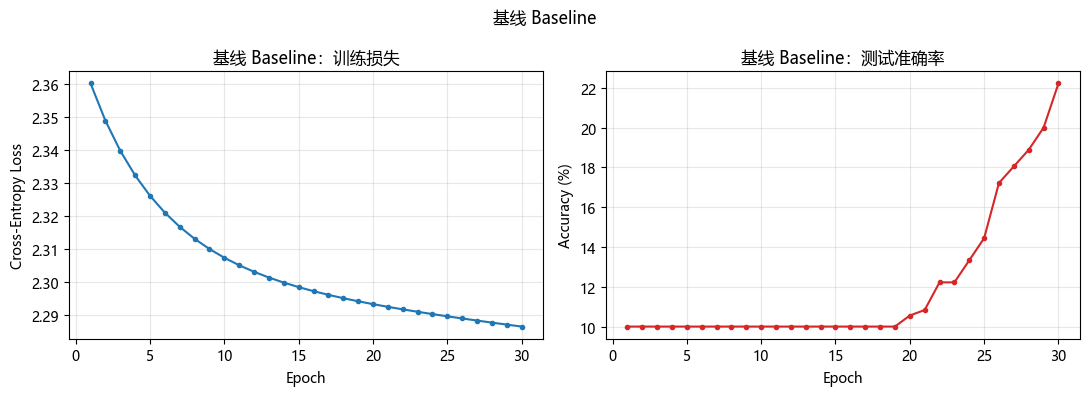

最终测试准确率：22.22%；训练耗时：0.0404s


In [23]:
baseline_history = run_experiment(0, '基线 Baseline', baseline, 'result_baseline.png')

### 2. 逐项改进实验

以下各组从基线配置出发。每个代码单元顶部的注释说明该组唯一的改动，运行后会立即保存对应曲线，并将测试准确率与训练耗时加入结果表。

开始运行：实验 1：Sigmoid → ReLU


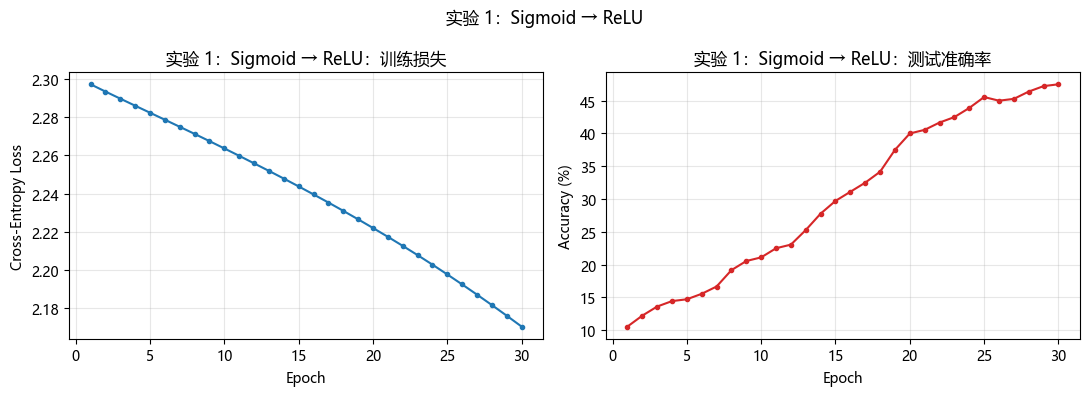

最终测试准确率：47.50%；训练耗时：0.0400s


In [24]:
# 实验 1：只把 Sigmoid 改为 ReLU。
exp1_config = {**baseline, 'activation': 'relu'}
exp1_history = run_experiment(1, '实验 1：Sigmoid → ReLU', exp1_config, 'result_exp1.png')

开始运行：实验 2：加深至 2 层 × 128


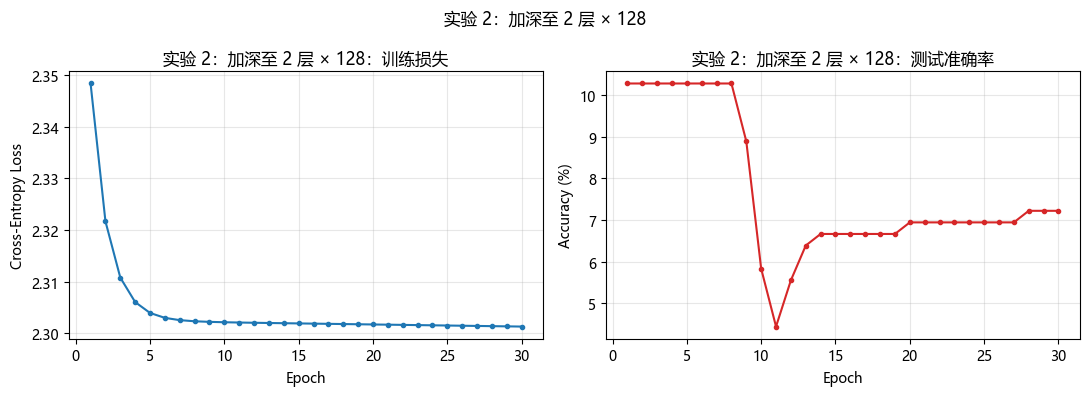

最终测试准确率：7.22%；训练耗时：0.0792s


In [25]:
# 实验 2：只把网络改为两层、每层 128 个神经元；仍使用 Sigmoid 和 SGD(0.1)。
exp2_config = {**baseline, 'hidden': (128, 128)}
exp2_history = run_experiment(2, '实验 2：加深至 2 层 × 128', exp2_config, 'result_exp2.png')

开始运行：实验 3：SGD → Adam(0.01)


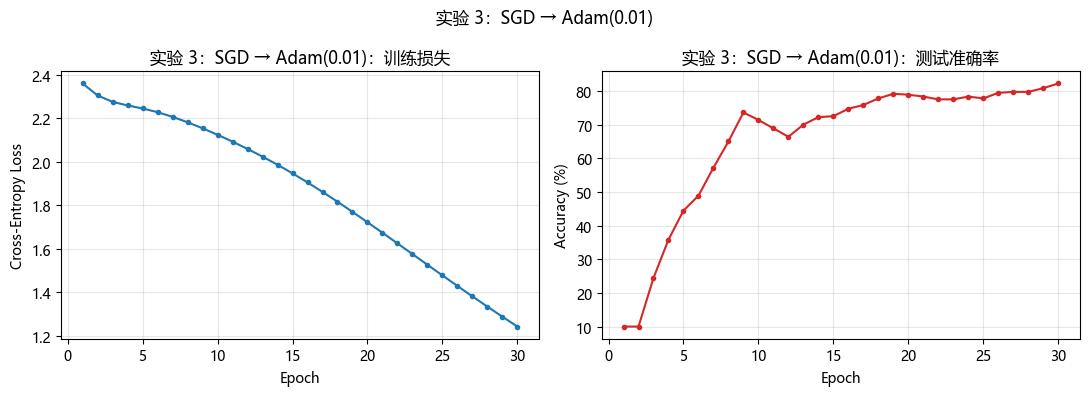

最终测试准确率：82.22%；训练耗时：0.0471s


In [26]:
# 实验 3：优化器改为 Adam；Adam 通常采用更小 lr=0.01，此处作为优化器方案的一部分记录。
exp3_config = {**baseline, 'optimizer': 'adam', 'lr': 0.01}
exp3_history = run_experiment(3, '实验 3：SGD → Adam(0.01)', exp3_config, 'result_exp3.png')

开始运行：实验 4：学习率 0.1 → 0.01


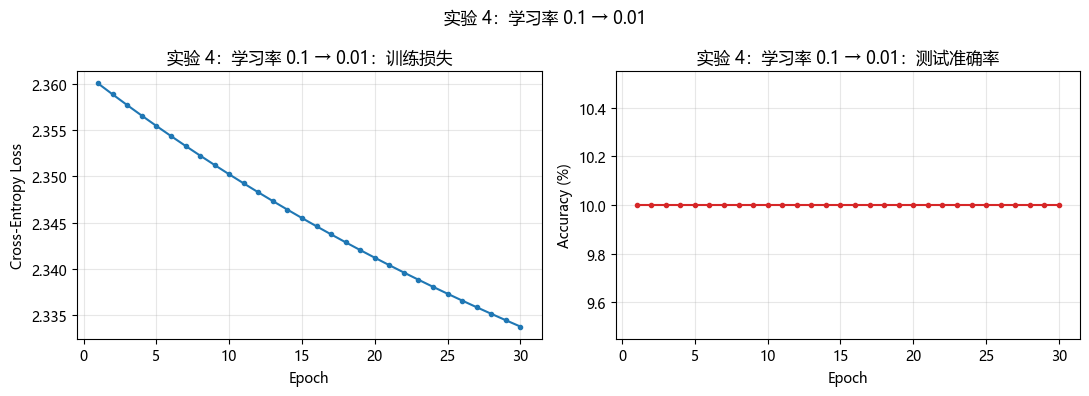

最终测试准确率：10.00%；训练耗时：0.0378s


In [27]:
# 实验 4：只把 SGD 的学习率从 0.1 调为 0.01。
exp4_config = {**baseline, 'lr': 0.01}
exp4_history = run_experiment(4, '实验 4：学习率 0.1 → 0.01', exp4_config, 'result_exp4.png')

开始运行：实验 5：L2 正则化


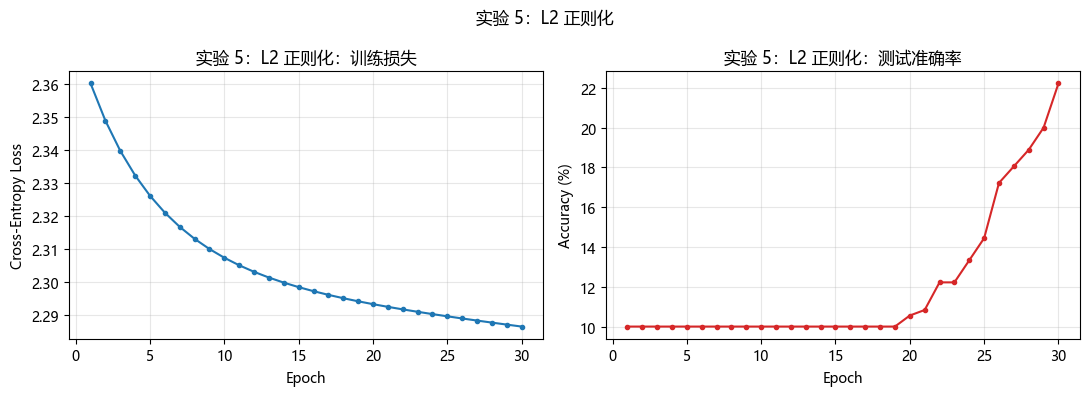

最终测试准确率：22.22%；训练耗时：0.0426s


In [28]:
# 实验 5：只加入 L2 正则化（weight_decay=1e-4）。
exp5_config = {**baseline, 'weight_decay': 1e-4}
exp5_history = run_experiment(5, '实验 5：L2 正则化', exp5_config, 'result_exp5.png')

开始运行：实验 6：Dropout(p=0.2)


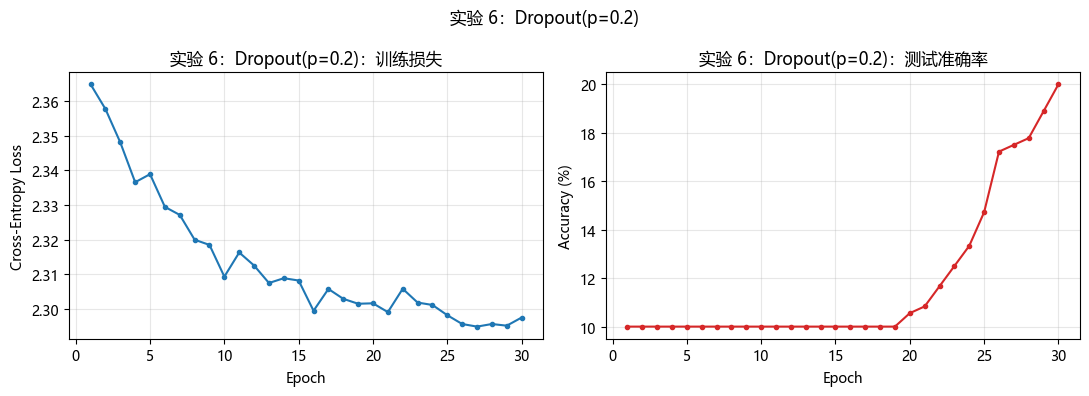

最终测试准确率：20.00%；训练耗时：0.0448s


In [29]:
# 实验 6：只加入 Dropout(p=0.2)。
exp6_config = {**baseline, 'dropout': 0.2}
exp6_history = run_experiment(6, '实验 6：Dropout(p=0.2)', exp6_config, 'result_exp6.png')

开始运行：实验 7：BatchNorm


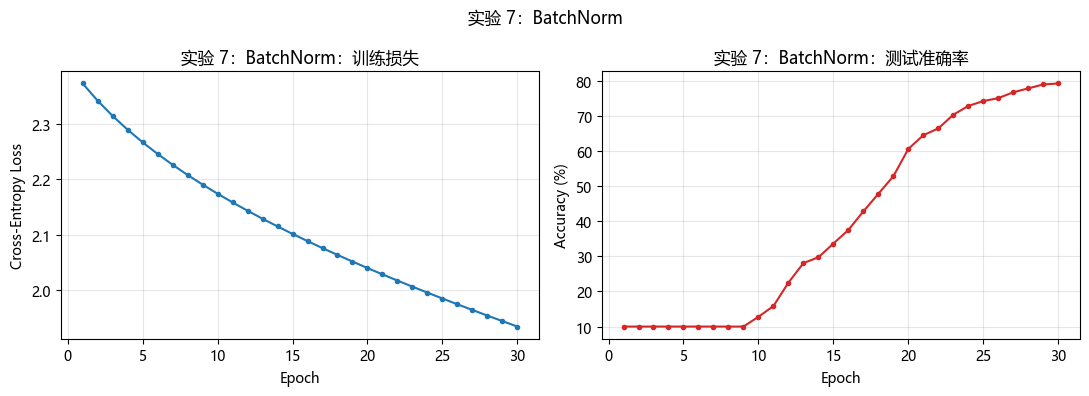

最终测试准确率：79.17%；训练耗时：0.0553s


In [30]:
# 实验 7：只在每个隐藏层后加入 BatchNorm1d。
exp7_config = {**baseline, 'use_batchnorm': True}
exp7_history = run_experiment(7, '实验 7：BatchNorm', exp7_config, 'result_exp7.png')

In [31]:
# 汇总基线和实验 1–7 的真实结果，用于填写报告表 3。
summary = sorted(records.values(), key=lambda row: row['组号'])
show_records(summary)
save_records_csv(summary, '实验结果汇总_基线至实验7.csv')

组号 | 实验名称 | 测试准确率(%) | 训练耗时(s) | 曲线文件 | 配置
----------------------------------------------------------------------------------------------------
0 | 基线 Baseline | 22.22 | 0.0404 | results\result_baseline.png | {'hidden': (32,), 'activation': 'sigmoid', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
1 | 实验 1：Sigmoid → ReLU | 47.5 | 0.04 | results\result_exp1.png | {'hidden': (32,), 'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
2 | 实验 2：加深至 2 层 × 128 | 7.22 | 0.0792 | results\result_exp2.png | {'hidden': (128, 128), 'activation': 'sigmoid', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
3 | 实验 3：SGD → Adam(0.01) | 82.22 | 0.0471 | results\result_exp3.png | {'hidden': (32,), 'activation': 'sigmoid', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
4 | 实验 4：学习率 0.1 → 0.01 | 10.0 | 0.0378 | r

## 3. 失败实验：学习率过大

在基线配置的基础上，仅将学习率设为 10.0。该实验用于观察参数更新步长过大时损失曲线的震荡或不稳定现象，不计入改进实验组数。

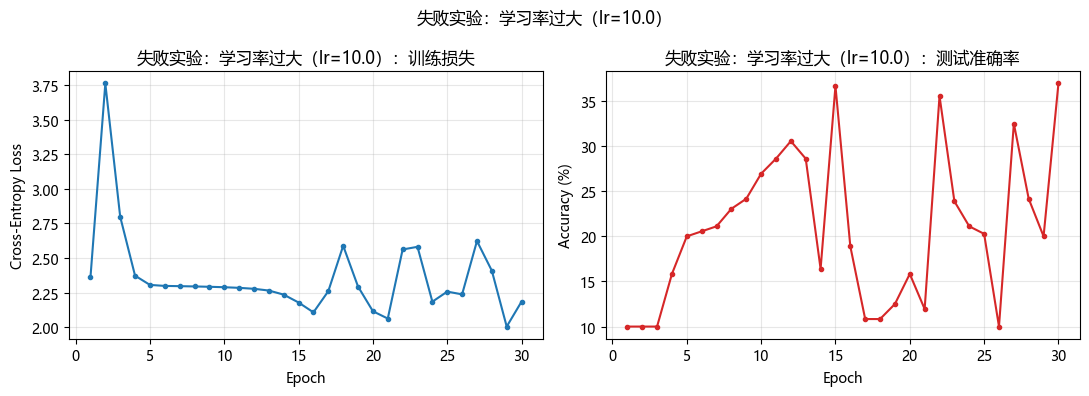

实验名称 | 学习率 | 最终测试准确率(%) | 训练耗时(s) | 曲线文件
----------------------------------------------------------------------------------------------------
失败实验：学习率过大 | 10.0 | 36.94 | 0.0566 | results\result_lr_too_big.png
已保存： results\失败实验结果.csv


In [32]:
# 必做失败实验：仅把基线学习率改成 10.0。该组不计入不少于 6 组改进实验。
failed_config = {**baseline, 'lr': 10.0}
failed_history = train_and_evaluate(failed_config)
failed_image = save_curve(failed_history, '失败实验：学习率过大（lr=10.0）', 'result_lr_too_big.png')
failed_records = [{
    '实验名称': '失败实验：学习率过大',
    '学习率': 10.0,
    '最终测试准确率(%)': round(failed_history['test_acc'][-1] * 100, 2),
    '训练耗时(s)': round(failed_history['seconds'], 4),
    '曲线文件': str(failed_image),
}]
show_records(failed_records)
save_records_csv(failed_records, '失败实验结果.csv')

## 4. 最优组合与三次复测

单项实验显示：两层 128 的 Sigmoid 网络明显退化，因此最优组合保留单隐藏层；ReLU、Adam 和 BatchNorm 均带来提升，故将这三项组合。数据划分和模型随机种子固定为 42，三次复测用于检验该全批量训练流程的可复现性。

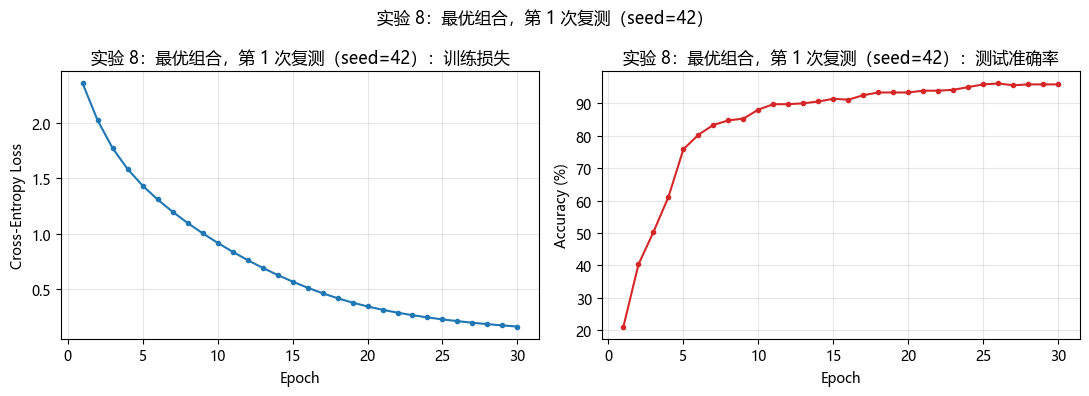

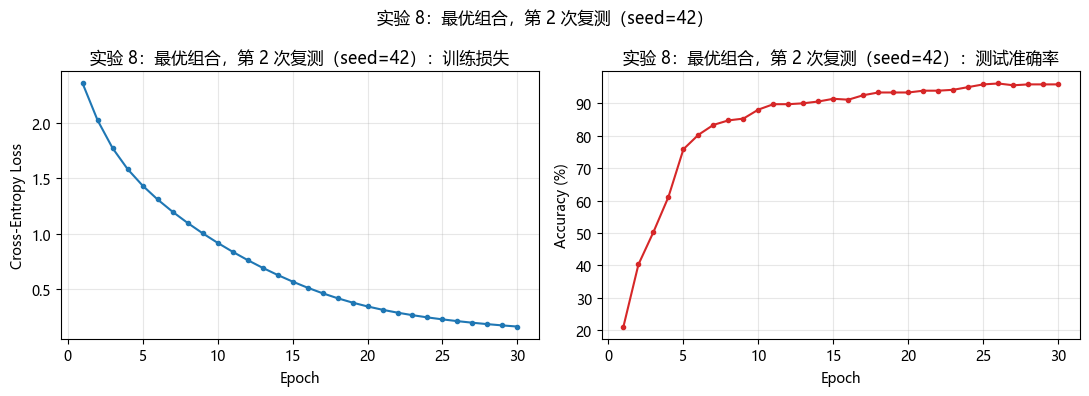

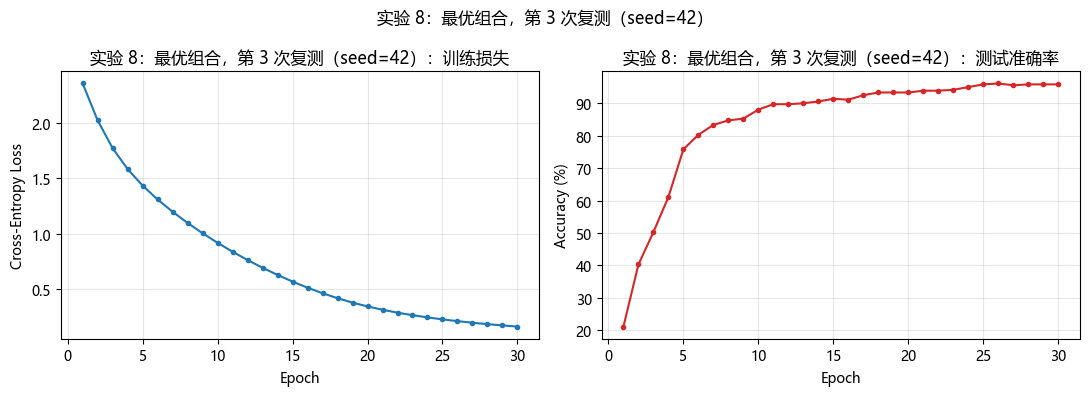

运行次数 | 模型初始化随机种子 | 测试准确率(%) | 训练耗时(s) | 曲线文件
----------------------------------------------------------------------------------------------------
1 | 42 | 95.83 | 0.0638 | results\result_exp8_run1.png
2 | 42 | 95.83 | 0.0706 | results\result_exp8_run2.png
3 | 42 | 95.83 | 0.0706 | results\result_exp8_run3.png
平均值 | - | 95.83 | 0.0683 | -
已保存： results\最优组合三次复测.csv


In [33]:
best_config = dict(
    hidden=(32,),
    activation='relu',
    optimizer='adam',
    lr=0.01,
    weight_decay=0.0,
    dropout=0.0,
    use_batchnorm=True,
)

repeat_seeds = [42, 42, 42]  # 严格固定随机种子；确定性全批量训练的三次结果通常相同。
best_records = []
for run_index, seed in enumerate(repeat_seeds, start=1):
    name = f'实验 8：最优组合，第 {run_index} 次复测（seed={seed}）'
    history = train_and_evaluate(best_config, seed=seed)
    image_name = f'result_exp8_run{run_index}.png'
    image_path = save_curve(history, name, image_name)
    best_records.append({
        '运行次数': run_index,
        '模型初始化随机种子': seed,
        '测试准确率(%)': round(history['test_acc'][-1] * 100, 2),
        '训练耗时(s)': round(history['seconds'], 4),
        '曲线文件': str(image_path),
    })

average_row = {
    '运行次数': '平均值',
    '模型初始化随机种子': '-',
    '测试准确率(%)': round(sum(row['测试准确率(%)'] for row in best_records) / len(best_records), 2),
    '训练耗时(s)': round(sum(row['训练耗时(s)'] for row in best_records) / len(best_records), 4),
    '曲线文件': '-',
}
best_summary_with_average = best_records + [average_row]
show_records(best_summary_with_average)
save_records_csv(best_summary_with_average, '最优组合三次复测.csv')

In [35]:
# 汇总最终结果，便于复制到报告的表 3、表 5。
best_for_table = {
    '组号': 8,
    '实验名称': '最优组合（3 次平均）',
    '测试准确率(%)': average_row['测试准确率(%)'],
    '训练耗时(s)': average_row['训练耗时(s)'],
    '曲线文件': 'result_exp8_run1.png（报告插图使用第 1 次曲线）',
    '配置': str(best_config),
}
final_summary = summary + [best_for_table]
show_records(final_summary)
save_records_csv(final_summary, '实验结果总表_可填报告.csv')

print('\n实验完成。报告所需 PNG 和 CSV 已保存在：', RESULT_DIR.resolve())

组号 | 实验名称 | 测试准确率(%) | 训练耗时(s) | 曲线文件 | 配置
----------------------------------------------------------------------------------------------------
0 | 基线 Baseline | 22.22 | 0.0404 | results\result_baseline.png | {'hidden': (32,), 'activation': 'sigmoid', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
1 | 实验 1：Sigmoid → ReLU | 47.5 | 0.04 | results\result_exp1.png | {'hidden': (32,), 'activation': 'relu', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
2 | 实验 2：加深至 2 层 × 128 | 7.22 | 0.0792 | results\result_exp2.png | {'hidden': (128, 128), 'activation': 'sigmoid', 'optimizer': 'sgd', 'lr': 0.1, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
3 | 实验 3：SGD → Adam(0.01) | 82.22 | 0.0471 | results\result_exp3.png | {'hidden': (32,), 'activation': 'sigmoid', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0, 'dropout': 0.0, 'use_batchnorm': False}
4 | 实验 4：学习率 0.1 → 0.01 | 10.0 | 0.0378 | r